## Data Collection

In [ ]:
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle
import os
plt.style.use("default")

stk_tickers = [
              '^NSEI',
              'ICICIBANK.NS',
              'AXISBANK.NS',
              'SBIN.NS',
              'RELIANCE.NS'
              ]
folder = "images"
os.makedirs(folder, exist_ok=True)
saved = 0

for ticker in stk_tickers:
  print('Downloading', ticker)

  df = yf.download(ticker, period="1y", interval="1d", 
                 progress=False, auto_adjust=False)

  window = 55

  for i in range(0, len(df) - window, window):
      saved += 1

      df_win = df.iloc[i:i+window]
      
      fig, ax = plt.subplots(figsize=(15, 10))
      
      for idx, row in df_win.iterrows():
          date = mdates.date2num(idx)
          o = float(row['Open'].iloc[0])    
          h = float(row['High'].iloc[0])    
          l = float(row['Low'].iloc[0])     
          c = float(row['Close'].iloc[0])   
          
          color = 'green' if c > o else 'red'
          ax.plot([date, date], [l, h], color='black', lw=1)
          height = abs(c - o)
          bottom = min(o, c)
          ax.add_patch(Rectangle((date-0.2, bottom), 0.4, height, 
                                facecolor=color, edgecolor='black'))
      
      ax.set_title(f"{ticker}", fontsize=14)
      ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
      plt.xticks(rotation=45)
      ax.grid(True, alpha=0.3)
      
      fname = f"image{saved:03d}.jpg"
      plt.savefig(os.path.join(folder, fname), dpi=150, bbox_inches='tight')
      plt.close()
      
print(f"{saved} clean images in {folder}")


4 clean images in images


## Train the Model

In [5]:
from ultralytics import YOLO

model = YOLO('yolov8l.pt')

model.train(data = 'conf.yaml', epochs=100, imgsz=480, batch=1, device=0, workers=0, amp=False,
                scale= 0.2,      # Zoom in/out)
                mosaic= 0.5,     # Mosaic (4 charts → 1) - POWERFUL!
                bgr=0.5,        #BGR Channel Swap 
)


Ultralytics 8.3.239  Python-3.12.9 torch-2.9.1+cu126 CUDA:0 (NVIDIA GeForce GTX 1650, 4096MiB)
engine\trainer: agnostic_nms=False, amp=False, augment=False, auto_augment=randaugment, batch=1, bgr=0.5, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=conf.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=480, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8l.pt, momentum=0.937, mosaic=0.5, multi_scale=False, name=train3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pre

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000002891D778B60>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0

## Test the model


0: 480x480 2 UpTrends, 962.7ms
1: 480x480 1 DownTrend, 3 UpTrends, 962.7ms
2: 480x480 1 DownTrend, 962.7ms
3: 480x480 1 UpTrend, 962.7ms
Speed: 1790.7ms preprocess, 962.7ms inference, 59.1ms postprocess per image at shape (1, 3, 480, 480)


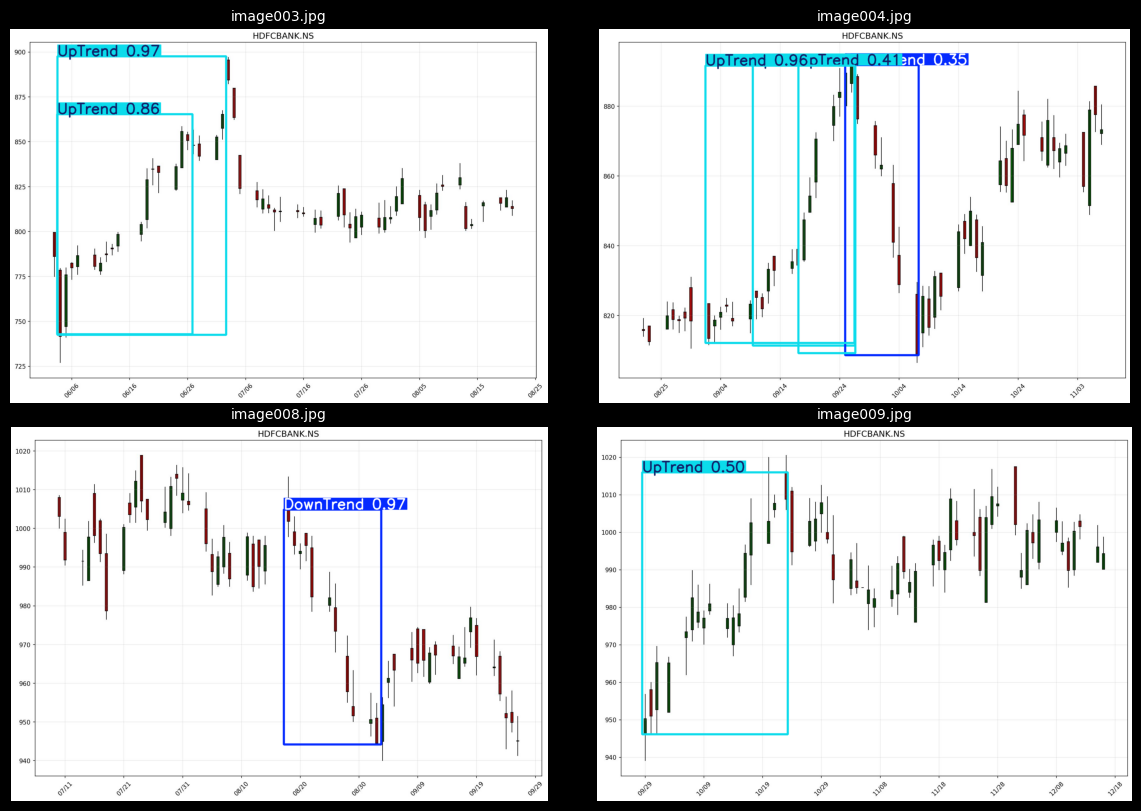

In [3]:
from ultralytics import YOLO
%matplotlib inline
import matplotlib.pyplot as plt

model = YOLO("runs/detect/train3/weights/best.pt")

image_paths = [
    "test_images/image003.jpg",
    "test_images/image004.jpg",
    "test_images/image008.jpg",
    "test_images/image009.jpg"
]

results = model(image_paths)

plt.figure(figsize=(12, 8))  

rows, cols = 2, 2

for i, (r, path) in enumerate(zip(results, image_paths), start=1):
    img = r.plot()[:, :, ::-1]  # BGR -> RGB
    plt.subplot(rows, cols, i)
    plt.imshow(img)
    plt.axis("off")
    plt.title(path.split("/")[-1], fontsize=10)

plt.tight_layout(pad=0.3, w_pad=0.1, h_pad=0.3)
plt.show()


In [1]:
print('Hello')


Hello
